In [ ]:
!git clone https://github.com/Gen1Code/COMP104CW2.git
%cd COMP104CW2
!ls
!find . -maxdepth 3 -type f -name "*.json" | head -n 50

Cloning into 'COMP104CW2'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 53 (delta 22), reused 49 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 35.66 MiB | 10.05 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Updating files: 100% (11/11), done.
/content/COMP104CW2
data  pydriller
./data/commons-lang.json
./data/cassandra.json
./data/kafka.json
./data/tomcat.json
./data/hadoop.json
./data/maven.json
./data/commons-io.json
./data/lucene.json


In [ ]:
!ls data | head

cassandra.json
commons-io.json
commons-lang.json
hadoop.json
kafka.json
lucene.json
maven.json
tomcat.json


In [ ]:
!pip -q install pandas

import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter, defaultdict

In [ ]:
repo_path = "data/cassandra.json"  # change if your file is elsewhere

with open(repo_path, "r", encoding="utf-8") as f:
    repo_json = json.load(f)

def to_commit_df(repo_json):
    repo_name = repo_json.get("name", "unknown")
    main_branch = repo_json.get("main_branch")
    commits = repo_json.get("commits", {})  # dict: hash -> commit_data

    rows = []
    for h, c in commits.items():
        branches = c.get("branches", [])
        rows.append({
            "repo": repo_name,
            "main_branch": main_branch,
            "hash": c.get("hash", h),
            "timestamp": c.get("timestamp"),
            "author": c.get("author"),
            "is_merge": bool(c.get("is_merge")),
            "branches": branches,
            "on_main": (main_branch in branches) if main_branch else False,
            "num_lines_changed": c.get("num_lines_changed"),
            "num_files_changed": c.get("num_files_changed"),
            "modified_files": c.get("modified_files", []),
        })

    df = pd.DataFrame(rows)

    # robust timestamp parsing
    df["dt"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["year"] = df["dt"].dt.year
    return df

df = to_commit_df(repo_json)
print("total commits loaded:", len(df))
df.head()

total commits loaded: 31501


,repo,main_branch,hash,timestamp,author,is_merge,branches,on_main,num_lines_changed,num_files_changed,modified_files,dt,year
0,cassandra,trunk,1f91e99223b0d1b7ed8390400d4a06ac08e4aa85,2009-03-02T07:57:22+00:00,Prashant Malik,False,[trunk],True,74502,344,"[{'filename': 'AnalyticsContext.java', 'modifi...",2009-03-02 07:57:22+00:00,2009
1,cassandra,trunk,cf56f8f3acbeac0ddff9ee3131ad7abe2a919ba3,2009-03-02T23:34:21+00:00,Prashant Malik,False,[trunk],True,156,4,"[{'filename': 'StorageService.java', 'modifica...",2009-03-02 23:34:21+00:00,2009
2,cassandra,trunk,4d09e9562df2548f9a1a42c4c78f1132a858e678,2009-03-14T02:12:52+00:00,Avinash Lakshman,False,[trunk],True,40,1,[],2009-03-14 02:12:52+00:00,2009
3,cassandra,trunk,e90036f6e1b2c799bef4842f69a0df9ee5b08ec9,2009-03-18T06:10:48+00:00,Avinash Lakshman,False,[trunk],True,183,4,"[{'filename': 'ChecksumManager.java', 'modific...",2009-03-18 06:10:48+00:00,2009
4,cassandra,trunk,16f30f16749fe4f75c94b17aa4a4b63df4ddb825,2009-03-19T19:48:21+00:00,Avinash Lakshman,False,[trunk],True,93,5,"[{'filename': 'AIORandomAccessFile.java', 'mod...",2009-03-19 19:48:21+00:00,2009


In [ ]:
def norm_path(s):
    return (s or "").replace("\\", "/").lower()

def cassandra_is_test_file(path):
    p = (path or "").replace("\\", "/")
    pl = p.lower()

    # path-based (best)
    if "/test/unit/" in pl or pl.startswith("test/") or "/test/" in pl:
        return True

    # filename-based fallback (when we only have "FooTest.java")
    fname = pl.split("/")[-1]
    return bool(re.match(r"^(test.*|.*test|.*tests)\.java$", fname))

def cassandra_is_prod_file(path):
    p = norm_path(path)
    return "/src/java/" in p

def classify_commits_cassandra(df):
    test_counts = []
    code_counts = []
    unknown_java_counts = []
    commit_types = []

    for _, row in df.iterrows():
        t = 0
        c = 0
        u = 0

        for mf in (row["modified_files"] or []):
            path = mf.get("new_path") or mf.get("old_path") or mf.get("filename")
            p = norm_path(path)

            # your mined data only saved .java files, but keep it safe anyway
            if not p.endswith(".java"):
                continue

            if cassandra_is_test_file(p):
                t += 1
            elif cassandra_is_prod_file(p):
                c += 1
            else:
                # java file but not in src/java or test/ (tools, examples, etc.)
                u += 1
                # choose ONE of these behaviours:
                # 1) treat unknown java as code (uncomment next line)
                c += 1

        if t > 0 and c == 0:
            ct = "test_only"
        elif c > 0 and t == 0:
            ct = "code_only"
        elif c > 0 and t > 0:
            ct = "mixed"
        else:
            ct = "none"

        test_counts.append(t)
        code_counts.append(c)
        unknown_java_counts.append(u)
        commit_types.append(ct)

    df = df.copy()
    df["test_changes"] = test_counts
    df["code_changes"] = code_counts
    df["unknown_java_changes"] = unknown_java_counts
    df["commit_type"] = commit_types
    return df

df = classify_commits_cassandra(df)

# the slice you typically analyse
df_main = df[(df["on_main"]) & (~df["is_merge"]) & (df["commit_type"] != "none")].copy()
print("non-merge main commits with java changes:", len(df_main))
df_main["commit_type"].value_counts()

non-merge main commits with java changes: 14280


,count
commit_type,
code_only,8849
mixed,4322
test_only,1109


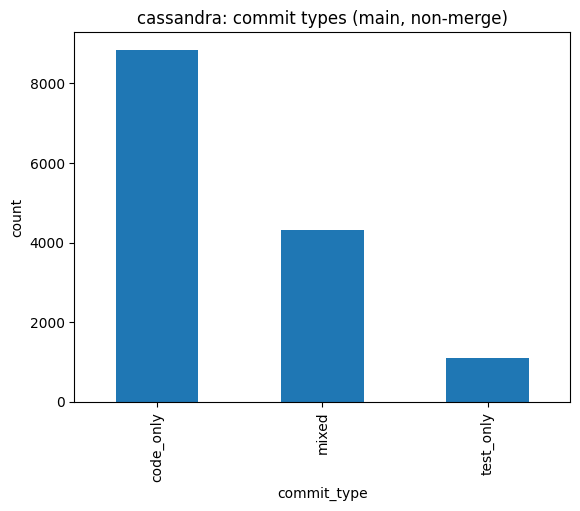

In [ ]:
counts = df_main["commit_type"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.xlabel("commit_type")
plt.ylabel("count")
plt.title(f"{df_main['repo'].iloc[0]}: commit types (main, non-merge)")
plt.show()

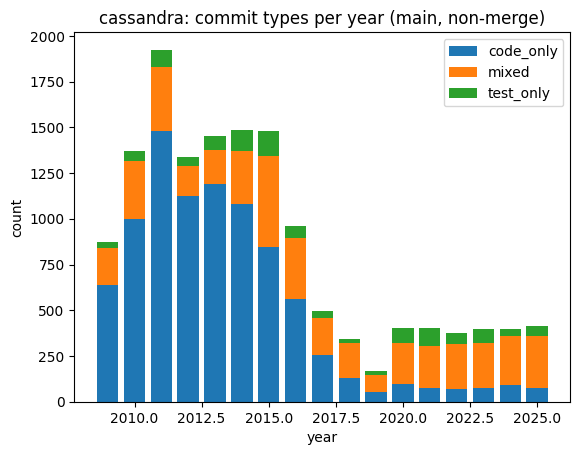

In [ ]:
by_year = df_main.groupby(["year", "commit_type"]).size().unstack(fill_value=0)

plt.figure()
bottom = None
for col in by_year.columns:
    if bottom is None:
        plt.bar(by_year.index, by_year[col], label=col)
        bottom = by_year[col]
    else:
        plt.bar(by_year.index, by_year[col], bottom=bottom, label=col)
        bottom = bottom + by_year[col]

plt.xlabel("year")
plt.ylabel("count")
plt.title(f"{df_main['repo'].iloc[0]}: commit types per year (main, non-merge)")
plt.legend()
plt.show()

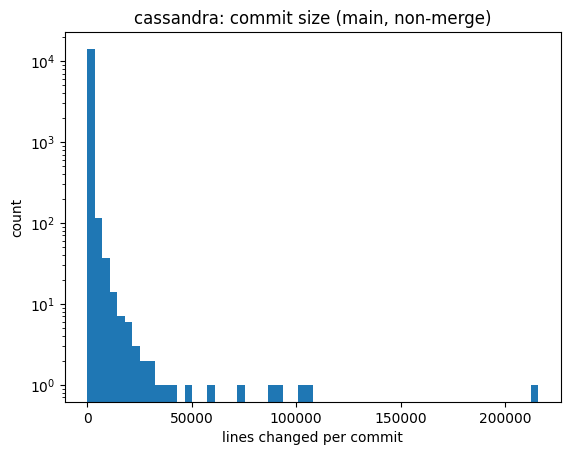

median lines changed: 35.5
95th percentile: 1090.1499999999978


In [ ]:
sizes = df_main["num_lines_changed"].dropna()

plt.figure()
plt.hist(sizes, bins=60)
plt.xlabel("lines changed per commit")
plt.ylabel("count")
plt.title(f"{df_main['repo'].iloc[0]}: commit size (main, non-merge)")
plt.yscale("log")
plt.show()

print("median lines changed:", float(sizes.median()) if len(sizes) else None)
print("95th percentile:", float(sizes.quantile(0.95)) if len(sizes) else None)

file intro order: Counter({'no_test_observed': 3638, 'test_parallel': 510, 'test_later': 435, 'test_first': 61}) total code files: 4644


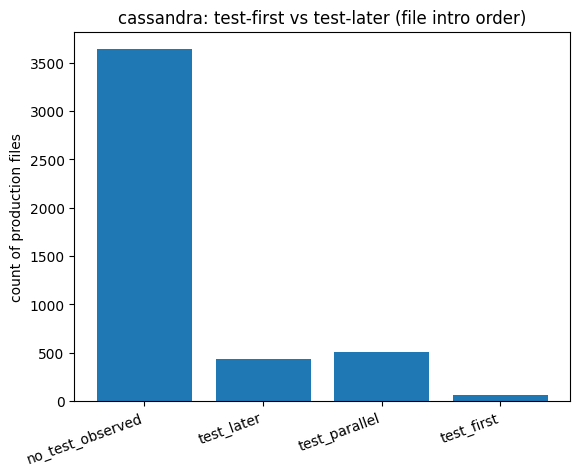

no_test_observed 78.34%
test_later 9.37%
test_parallel 10.98%
test_first 1.31%


In [ ]:
def base_name(path):
    p = norm_path(path)
    return p.split("/")[-1] if p else ""

def map_test_to_code_filename(test_filename):
    # FooTest.java -> Foo.java
    m = re.match(r"^(.*)test\.java$", test_filename.lower())
    if m and m.group(1):
        return m.group(1) + ".java"

    # TestFoo.java -> Foo.java
    m = re.match(r"^test(.*)\.java$", test_filename.lower())
    if m and m.group(1):
        return m.group(1) + ".java"

    return None

def compute_first_seen_loose(df_filtered):
    first_code = {}  # basename -> dt
    first_test = {}  # basename -> dt

    df_sorted = df_filtered.sort_values("dt")
    for _, row in df_sorted.iterrows():
        dt = row["dt"]
        if pd.isna(dt):
            continue
        for mf in (row["modified_files"] or []):
            path = mf.get("new_path") or mf.get("old_path") or mf.get("filename")
            if not path:
                continue
            p = path.replace("\\", "/")
            pl = p.lower()
            if not pl.endswith(".java"):
                continue

            fname = pl.split("/")[-1]

            if cassandra_is_test_file(p):
                first_test.setdefault(fname, dt)
            else:
                first_code.setdefault(fname, dt)

    return first_code, first_test

def test_first_summary(df_main_nonmerge):
    first_code, first_test = compute_first_seen_loose(df_main_nonmerge)

    # build mapping code filename -> earliest test time
    code_to_test_times = defaultdict(list)
    for tname, tdt in first_test.items():
        code = map_test_to_code_filename(tname)
        if code:
            code_to_test_times[code].append(tdt)

    results = Counter()
    for code_name, code_dt in first_code.items():
        test_times = code_to_test_times.get(code_name, [])
        if not test_times:
            results["no_test_observed"] += 1
            continue
        test_dt = min(test_times)

        if test_dt < code_dt:
            results["test_first"] += 1
        elif test_dt == code_dt:
            results["test_parallel"] += 1
        else:
            results["test_later"] += 1

    total = sum(results.values())
    return results, total

results, total = test_first_summary(df_main)
print("file intro order:", results, "total code files:", total)

# plot
labels = list(results.keys())
vals = [results[k] for k in labels]

plt.figure()
plt.bar(labels, vals)
plt.xticks(rotation=20, ha="right")
plt.ylabel("count of production files")
plt.title(f"{df_main['repo'].iloc[0]}: test-first vs test-later (file intro order)")
plt.show()

if total > 0:
    for k in labels:
        print(k, f"{results[k]/total*100:.2f}%")

In [ ]:
ct_pct = (df_main["commit_type"].value_counts(normalize=True) * 100)
sizes = df_main["num_lines_changed"].dropna()

summary = {
    "repo": df_main["repo"].iloc[0],
    "nonmerge_main_commits": len(df_main),
    "%code_only_commits": float(ct_pct.get("code_only", 0.0)),
    "%test_only_commits": float(ct_pct.get("test_only", 0.0)),
    "%mixed_commits": float(ct_pct.get("mixed", 0.0)),
    "median_lines_changed": float(sizes.median()) if len(sizes) else None,
    "p95_lines_changed": float(sizes.quantile(0.95)) if len(sizes) else None,
    "%test_first_files": (results["test_first"]/total*100) if total else None,
    "%test_parallel_files": (results["test_parallel"]/total*100) if total else None,
    "%test_later_files": (results["test_later"]/total*100) if total else None,
    "%no_test_observed_files": (results["no_test_observed"]/total*100) if total else None,
}

summary

{'repo': 'cassandra',
 'nonmerge_main_commits': 14280,
 '%code_only_commits': 61.96778711484594,
 '%test_only_commits': 7.766106442577031,
 '%mixed_commits': 30.26610644257703,
 'median_lines_changed': 35.5,
 'p95_lines_changed': 1090.1499999999978,
 '%test_first_files': 1.313522825150732,
 '%test_parallel_files': 10.981912144702841,
 '%test_later_files': 9.366925064599483,
 '%no_test_observed_files': 78.33763996554694}

In [ ]:
def map_test_to_code_filename(test_filename):
    tf = test_filename.lower()
    m = re.match(r"^(.*)test\.java$", tf)
    if m and m.group(1):
        return m.group(1) + ".java"
    m = re.match(r"^test(.*)\.java$", tf)
    if m and m.group(1):
        return m.group(1) + ".java"
    return None

def test_first_summary_loose(df_main_nonmerge):
    first_code, first_test = compute_first_seen_loose(df_main_nonmerge)

    code_to_test_times = defaultdict(list)
    for tname, tdt in first_test.items():
        code = map_test_to_code_filename(tname)
        if code:
            code_to_test_times[code].append(tdt)

    results = Counter()
    for code_name, code_dt in first_code.items():
        test_times = code_to_test_times.get(code_name, [])
        if not test_times:
            results["no_test_observed"] += 1
            continue
        test_dt = min(test_times)
        if test_dt < code_dt:
            results["test_first"] += 1
        elif test_dt == code_dt:
            results["test_parallel"] += 1
        else:
            results["test_later"] += 1

    total = sum(results.values())
    return results, total

In [ ]:
# pick one commit that has some modified_files
sample = df_main[df_main["modified_files"].apply(lambda x: isinstance(x, list) and len(x) > 0)].iloc[0]
sample["modified_files"][:5]

[{'filename': 'AnalyticsContext.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/AnalyticsContext.java',
  'old_path': None,
  'num_lines_added': 788,
  'num_lines_deleted': 0},
 {'filename': 'AnalyticsException.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/AnalyticsException.java',
  'old_path': None,
  'num_lines_added': 47,
  'num_lines_deleted': 0},
 {'filename': 'DBAnalyticsSource.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/DBAnalyticsSource.java',
  'old_path': None,
  'num_lines_added': 182,
  'num_lines_deleted': 0},
 {'filename': 'IAnalyticsSource.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/IAnalyticsSource.java',
  'old_path': None,
  'num_lines_added': 35,
  'num_lines_deleted': 0},
 {'filename': 'MetricValue.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/MetricValue.java',
  'old_path': None,

In [ ]:
total_java_files = df_main["test_changes"].sum() + df_main["code_changes"].sum()
print("total test file changes:", df_main["test_changes"].sum())
print("total code file changes:", df_main["code_changes"].sum())
print("share test file changes:", df_main["test_changes"].sum() / max(1, total_java_files))

total test file changes: 22482
total code file changes: 68626
share test file changes: 0.24676208455898493


In [ ]:
print("sum test_changes:", df_main["test_changes"].sum())
print("sum code_changes:", df_main["code_changes"].sum())

sum test_changes: 22482
sum code_changes: 68626


In [ ]:
row = df_main[df_main["modified_files"].apply(lambda x: isinstance(x, list) and len(x) > 0)].iloc[0]
row["modified_files"][:5]

[{'filename': 'AnalyticsContext.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/AnalyticsContext.java',
  'old_path': None,
  'num_lines_added': 788,
  'num_lines_deleted': 0},
 {'filename': 'AnalyticsException.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/AnalyticsException.java',
  'old_path': None,
  'num_lines_added': 47,
  'num_lines_deleted': 0},
 {'filename': 'DBAnalyticsSource.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/DBAnalyticsSource.java',
  'old_path': None,
  'num_lines_added': 182,
  'num_lines_deleted': 0},
 {'filename': 'IAnalyticsSource.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/IAnalyticsSource.java',
  'old_path': None,
  'num_lines_added': 35,
  'num_lines_deleted': 0},
 {'filename': 'MetricValue.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/MetricValue.java',
  'old_path': None,

In [ ]:
results, total = test_first_summary_loose(df_main)
print(results, "total:", total)

Counter({'no_test_observed': 3638, 'test_parallel': 510, 'test_later': 435, 'test_first': 61}) total: 4644


In [ ]:
print("sum test_changes:", df_main["test_changes"].sum())
print("sum code_changes:", df_main["code_changes"].sum())

sum test_changes: 22482
sum code_changes: 68626


In [ ]:
df_main["test_changes"].sum()

np.int64(22482)

In [ ]:
row["modified_files"][:3]

[{'filename': 'AnalyticsContext.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/AnalyticsContext.java',
  'old_path': None,
  'num_lines_added': 788,
  'num_lines_deleted': 0},
 {'filename': 'AnalyticsException.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/AnalyticsException.java',
  'old_path': None,
  'num_lines_added': 47,
  'num_lines_deleted': 0},
 {'filename': 'DBAnalyticsSource.java',
  'modification_type': 1,
  'new_path': 'src/org/apache/cassandra/analytics/DBAnalyticsSource.java',
  'old_path': None,
  'num_lines_added': 182,
  'num_lines_deleted': 0}]

In [ ]:
def norm(p):
    return (p or "").replace("\\", "/")

def is_test_path(p):
    pl = norm(p).lower()
    return pl.startswith("test/") or "/test/" in pl

def is_prod_path(p):
    pl = norm(p).lower()
    # Cassandra prod often under src/... (your data shows src/org/...)
    return pl.startswith("src/") and not is_test_path(pl)

def class_name_from_path(p):
    # returns "Foo" from ".../Foo.java"
    fname = norm(p).split("/")[-1]
    return fname[:-5] if fname.lower().endswith(".java") else None

def candidate_test_paths(prod_path):
    # map src/.../pkg/Foo.java -> test/.../pkg/FooTest.java etc.
    p = norm(prod_path)
    if not p.lower().startswith("src/"):
        return []

    rel = p[4:]  # drop "src/"
    base_dir = "/".join(rel.split("/")[:-1])
    cls = class_name_from_path(p)
    if not cls:
        return []

    # common Cassandra test roots (keep several, we’ll match what exists)
    test_roots = ["test/unit", "test", "test/distributed"]

    candidates = []
    for root in test_roots:
        candidates += [
            f"{root}/{base_dir}/{cls}Test.java",
            f"{root}/{base_dir}/Test{cls}.java",
            f"{root}/{base_dir}/{cls}Tests.java",
        ]
    return candidates

def compute_first_seen_paths(df_filtered):
    first_prod = {}  # prod_path -> dt
    first_test = {}  # test_path -> dt

    df_sorted = df_filtered.sort_values("dt")
    for _, row in df_sorted.iterrows():
        dt = row["dt"]
        if pd.isna(dt):
            continue
        for mf in (row["modified_files"] or []):
            path = mf.get("new_path") or mf.get("old_path") or mf.get("filename")
            if not path:
                continue
            pl = norm(path).lower()
            if not pl.endswith(".java"):
                continue

            if is_test_path(path):
                first_test.setdefault(norm(path), dt)
            elif is_prod_path(path):
                first_prod.setdefault(norm(path), dt)
            else:
                # if it’s java but not clearly test/prod, ignore for this metric
                pass

    return first_prod, first_test

def test_first_summary_cassandra(df_main_nonmerge):
    first_prod, first_test = compute_first_seen_paths(df_main_nonmerge)

    results = Counter()

    for prod_path, prod_dt in first_prod.items():
        candidates = candidate_test_paths(prod_path)
        # keep only candidates that actually exist in first_test
        existing = [first_test[c] for c in candidates if c in first_test]

        if not existing:
            results["no_test_observed"] += 1
            continue

        test_dt = min(existing)
        if test_dt < prod_dt:
            results["test_first"] += 1
        elif test_dt == prod_dt:
            results["test_parallel"] += 1
        else:
            results["test_later"] += 1

    total = sum(results.values())
    return results, total

results, total = test_first_summary_cassandra(df_main)
print(results, "total prod files:", total)

Counter({'no_test_observed': 5064, 'test_later': 43, 'test_parallel': 2}) total prod files: 5109


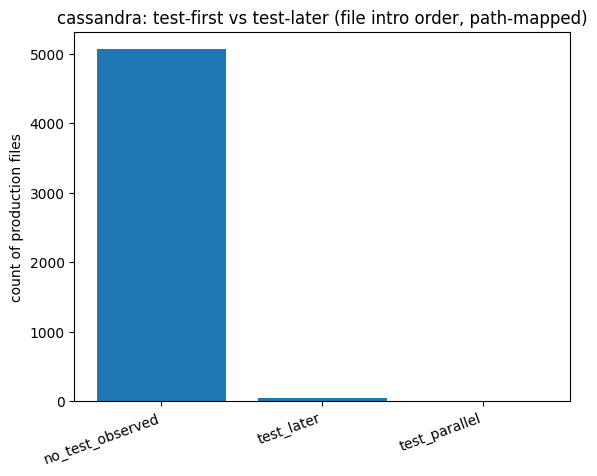

no_test_observed 99.12%
test_later 0.84%
test_parallel 0.04%


In [ ]:
labels = list(results.keys())
vals = [results[k] for k in labels]

plt.figure()
plt.bar(labels, vals)
plt.xticks(rotation=20, ha="right")
plt.ylabel("count of production files")
plt.title("cassandra: test-first vs test-later (file intro order, path-mapped)")
plt.show()

if total:
    for k in labels:
        print(k, f"{results[k]/total*100:.2f}%")

In [ ]:
df_main["test_changes"].sum()

np.int64(22482)

In [ ]:
matches = []
first_prod, first_test = compute_first_seen_paths(df_main)  # from the path-based version

for prod_path, prod_dt in first_prod.items():
    cands = candidate_test_paths(prod_path)
    existing = [(c, first_test[c]) for c in cands if c in first_test]
    if existing:
        test_path, test_dt = min(existing, key=lambda x: x[1])
        matches.append((prod_path, prod_dt, test_path, test_dt))

print("num matched prod↔test pairs:", len(matches))
for row in matches[:10]:
    print(row)

num matched prod↔test pairs: 45
('src/org/apache/cassandra/concurrent/DebuggableScheduledThreadPoolExecutor.java', Timestamp('2009-03-02 07:57:22+0000', tz='UTC'), 'test/unit/org/apache/cassandra/concurrent/DebuggableScheduledThreadPoolExecutorTest.java', Timestamp('2015-05-18 19:18:24+0000', tz='UTC'))
('src/org/apache/cassandra/concurrent/DebuggableThreadPoolExecutor.java', Timestamp('2009-03-02 07:57:22+0000', tz='UTC'), 'test/unit/org/apache/cassandra/concurrent/DebuggableThreadPoolExecutorTest.java', Timestamp('2010-01-14 03:18:34+0000', tz='UTC'))
('src/org/apache/cassandra/config/CFMetaData.java', Timestamp('2009-03-02 07:57:22+0000', tz='UTC'), 'test/unit/org/apache/cassandra/config/CFMetaDataTest.java', Timestamp('2011-08-24 18:52:23+0000', tz='UTC'))
('src/org/apache/cassandra/config/DatabaseDescriptor.java', Timestamp('2009-03-02 07:57:22+0000', tz='UTC'), 'test/unit/org/apache/cassandra/config/DatabaseDescriptorTest.java', Timestamp('2009-05-06 02:00:06+0000', tz='UTC'))
('